# Lab Seven: Sequential Networks

Teammates: David Guo, Zi Ling

## 1. Preparation
### 1.1 Data Exploration and Class Construction

In [1]:
import pandas as pd
df = pd.read_csv("tweet_emotions.csv")
df.head()

,tweet_id,sentiment,content
0,1956967341,empty,@tiffanylue i know i was listenin to bad habi...
1,1956967666,sadness,Layin n bed with a headache ughhhh...waitin o...
2,1956967696,sadness,Funeral ceremony...gloomy friday...
3,1956967789,enthusiasm,wants to hang out with friends SOON!
4,1956968416,neutral,@dannycastillo We want to trade with someone w...


In [2]:
print(df["sentiment"].value_counts())

sentiment
neutral       8638
worry         8459
happiness     5209
sadness       5165
love          3842
surprise      2187
fun           1776
relief        1526
hate          1323
empty          827
enthusiasm     759
boredom        179
anger          110
Name: count, dtype: int64



**Business Case and Dataset Introduction**

Advertising in social media is essential for both platforms and brands. On X (formerly Twitter), billions of dollars are spent on advertising every year [1]. X also provides a wide range of targeting strategies, such as demographic, keyword, event, and interest targeting—to help advertisers improve campaign effectiveness [2].

However, effective ad delivery is not only about targeting the right audience, brand safety is equally important. According to Lee et al. (2021), brand safety refers to “ensuring that a brand’s ad should not appear adjacent to content or in a context that can damage the advertised brand” [3]. Because ads on X frequently appear next to user-generated content, the emotional tone of the surrounding tweets can influence users’ perception of the ad and even the brand itself.

Therefore, if we could automatically understand tweet content and recognize its emotional polarity, advertisers could strategically place ads next to positive tweets while avoiding negative contexts. Such sentiment-aware placement also has the potential to improve ad performance metrics such as clicks and app installs, while protecting brand reputation.

In this lab, we use the “Emotion Detection from Text” dataset from Kaggle (https://www.kaggle.com/datasets/pashupatigupta/emotion-detection-from-text) to build a tweet emotion classification model. The dataset contains three columns: tweet_id, content, and sentiment. It includes 40,000 records distributed across 13 emotion categories. However, the distribution is highly imbalanced, categories such as neutral and worry have over 8,000 samples, while others such as boredom and anger contain fewer than 200 samples.

To address this, the following preparation steps include class variable construction, label consolidation, sampling for class balancing, train/test splitting, and text preprocessing, producing a cleaner and more suitable dataset for training sentiment classification models.

Reference:

[1] Statista, “X (Twitter) advertising revenue worldwide from 2019 to 2024,” Statista, 2024. [Online]. Available: https://www.statista.com/statistics/1344350/twitter-net-ad-revenue-worldwide/.

[2] X Business, “Targeting,” X for Business, 2024. [Online]. Available: https://business.x.com/en/advertising/targeting.

[3] C. Lee, J. Kim, and J. S. Lim, “Spillover effects of brand safety violations in social media,” Journal of Current Issues & Research in Advertising, vol. 42, no. 4, pp. 354–371, 2021, doi: 10.1080/10641734.2021.1905572.


In [3]:

# ======Label (original) deletion===============
labels_to_delete = ["empty","surprise"]
df_deleted = df[~df["sentiment"].isin(labels_to_delete)].copy()



# ====== create the new 3-class variable===============
positive = {"happiness", "love", "fun", "relief", "enthusiasm"}
negative = {"worry", "sadness", "hate", "boredom", "anger"}

def map_class_int(label):
	if label in positive:
		return 2     # positive
	elif label in negative:
		return 0     # negative
	else:
		return 1     # neutral

df_deleted["class_int"] = df_deleted["sentiment"].apply(map_class_int)

print(df_deleted["class_int"].value_counts())

class_int
0    15236
2    13112
1     8638
Name: count, dtype: int64


In [4]:
# =========== undersampling to neutral class 8638 to achieve balance ========

balanced_list = []

for label, group in df_deleted.groupby("class_int"):
	sampled = group.sample(n=8638, random_state=42, replace=False)
	balanced_list.append(sampled)

df_balanced = pd.concat(balanced_list, ignore_index=True)

print(df_balanced["class_int"].value_counts())


# ====== final dataframe with only content and class_int ========
df_final = df_balanced[["content", "class_int"]].copy()

df_final.info()


class_int
0    8638
1    8638
2    8638
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25914 entries, 0 to 25913
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   content    25914 non-null  object
 1   class_int  25914 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 405.0+ KB


**Class Variable and Final Dataset Preparation**

Based on the original sentiment labels, we created a coarse-grained class variable with three values: positive, negative, and neutral. This is because for our business case, we primarily care about separating positive from negative contexts to support safer and more effective ad placement.

To construct this three-class target variable, we first removed two ambiguous labels, “empty” and “surprise”, which do not consistently convey positive or negative meaning. We then directly mapped the remaining original sentiment labels into the new classes. Specifically, we defined happiness, love, fun, relief, and enthusiasm as positive (class_int = 2), while worry, sadness, hate, boredom, and anger were defined as negative (class_int = 0). And the neatral-sentiment tweets were assigned to the neutral class (class_int = 1).

The resulting coarse classes were still imbalanced, with 15,236 negative, 13,112 positive, and 8,638 neutral samples. To achieve a balanced dataset, we applied random undersampling to the positive and negative classes, reducing each class to match the neutral class size of 8,638 samples. This produced a final dataset with 8,638 samples per class, totaling 25,914 balanced observations.

Finally, we kept only the tweet text and the integer class label, forming a clean dataset (df_final) suitable for model training.

The final dataset we use for classification is a balanced three-class dataset, with 8,638 samples in each class. The class labels are encoded as integers, where 2 represents positive, 0 represents negative, and 1 represents neutral. The dataset contains a total of 25,914 rows and two columns: the tweet content and the corresponding class label.

In [5]:
# count words in each content, for later setting max_tweet_length
df_final["word_count"] = df_final["content"].apply(lambda x: len(str(x).split()))
df_final["word_count"].describe()

count    25914.000000
mean        13.003126
std          6.998555
min          1.000000
25%          7.000000
50%         12.000000
75%         18.000000
max         34.000000
Name: word_count, dtype: float64

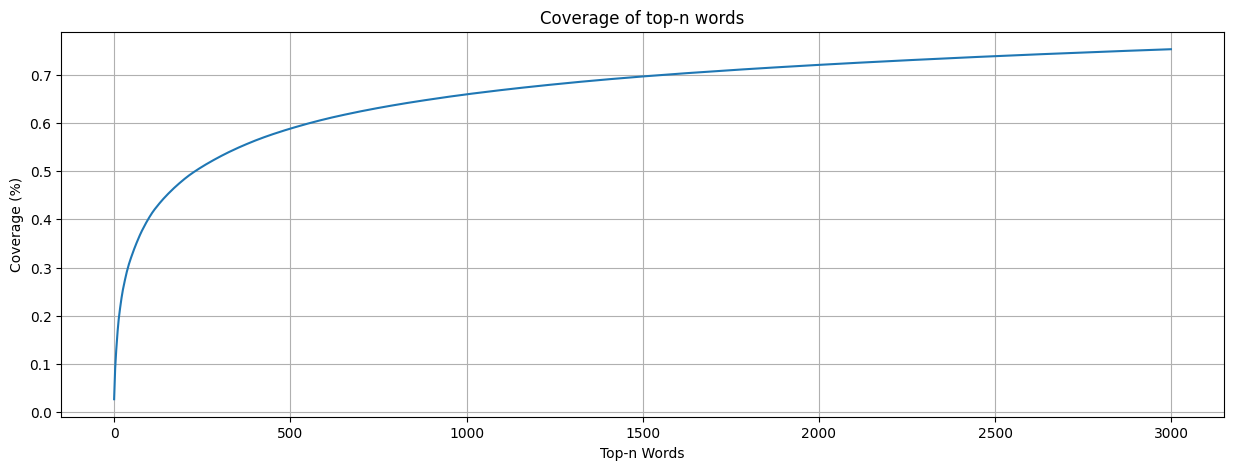

In [6]:
# count words frequency, for later setting top_words, GPT debugs the counting code

from collections import Counter
import matplotlib.pyplot as plt

# get all words in the content, and count the frequency
all_words = " ".join(df_final["content"].astype(str)).split()
word_counts = Counter(all_words)

# create plot for cumulative coverage
freq_df = pd.DataFrame(word_counts.most_common(), columns=["word", "count"]) # need to transform into DataFrame
freq_df["cumulative"] = freq_df["count"].cumsum()
total_count = freq_df["count"].sum()
freq_df["coverage"] = freq_df["cumulative"] / total_count

N = 3000  # only plot top-n words
plt.figure(figsize=(15,5))
plt.plot(freq_df["coverage"].iloc[:N])

plt.title("Coverage of top-n words")
plt.xlabel("Top-n Words")
plt.ylabel("Coverage (%)")

plt.grid()
plt.show()

**Choosing Max Tweet Length and Top-N Words**

To determine appropriate values for maximum sequence length and vocabulary size, we analyzed both the word count per tweet and the coverage of the top-n most frequent words.

For the maximum sequence length, our analysis showed that 75% of tweets contain 18 words or fewer, and the longest tweet contains only 34 words. This aligns with the nature of tweets being short text. Therefore, we decided to include the full content of each tweet, since the computational cost for such short sequences is minimal.

For the vocabulary size, we examined how much of the dataset is covered by the top-n most frequent words. The plot showed that the top 500 words covered about 59% of all word occurrences, while the top 1,000 words covered about 66%. We finally selected 1,500 words because coverage reaches approximately 70% at this point and increases very slowly afterward, indicating diminishing returns.

### 1.2 Performance Evaluation Method

For this lab, we do not use accuracy as the primary evaluation metric, because accuracy treats all types of errors equally, and in our ad-safety business case, errors related to the negative classes have more business consequences. Therefore, we evaluate our models using a combination of F-scores on different classes and define the overall performance as:

$$
\text{Final Score} = \frac{F2_{\text{negative}} + F1_{\text{neutral}} + F1_{\text{positive}}}{3}
$$

Here, F2 refers to the F-beta score with beta = 2, which weights recall more heavily than precision.

This design reflects our business case of brand safety in ad placement. From the advertiser’s perspective, the most critical risk is failing to detect negative contexts and placing ads next to negative tweets. Such false negatives (negative tweets misclassified as non-negative) may harm brand perception and violate brand-safety guidelines. Therefore, for the negative class we emphasize recall more than precision and use F2 instead of F1.

For the neutral and positive classes, the cost of misclassification is less severe. Mislabeling a neutral tweet as positive, or vice versa, mainly affects potential uplift in engagement but is less likely to cause brand damage. For these classes, we care about a balanced trade-off between precision and recall, so the standard F1 score is appropriate. 

Averaging the three class-wise scores ensures that the model must perform reasonably well across all sentiment categories, while still giving extra importance to recall on the negative class, which is most critical for the business and policy objective of safe and responsible ad placement.

### 1.3 Train/Test Splitting Method

In [7]:
# 80/20 stratified train/test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
	df_final["content"],
	df_final["class_int"],
	test_size=0.2,
	random_state=42,
	stratify=df_final["class_int"]
)

**Train/Test Splitting Method Selection**

We use an 80/20 stratified train/test split for this project for the following reasons:

1.	After preprocessing and balancing, the final dataset contains 25,914 samples with equal number samples of negative, neutral, and positive instances. An 80/20 split results in 20,731 training samples and 5,183 test samples, which is sufficient for both model learning and reliable evaluation. Stratification ensures that class distributions remain consistent across the training and test sets.

2.	During model training, we further split 20% of the training data as a validation set using validation_split. This validation set is used for model selection and hyperparameter tuning, while the test set remains completely unseen until the final score calculation, ensuring a clean and unbiased performance comparison.

3.	Although k-fold cross-validation is common, it is less suitable for sequential text modeling. Tokenization, vocabulary construction, and sequence padding must be fit only on training data, and repeating these steps across multiple folds would be computationally expensive and unrealistic. In practice, sentiment models are trained once on historical data and then applied to new tweets. The chosen splitting strategy closely mirrors this real-world usage.

### 1.4 Preprocessing

In [8]:
import tensorflow as tf
from tensorflow.keras.layers import TextVectorization

top_words = 1500          # 1500 words can cover ~70% according to the above plot
max_tweet_length = 35               # all the contents' word_count <= 34

# using Keras TextVectorization layer to vectorize text, instead of using Tokenizer (suggested by GPT)
vectorizer = TextVectorization(
	max_tokens=top_words,
	output_sequence_length=max_tweet_length,
	standardize="lower_and_strip_punctuation",
	split="whitespace"
)


vectorizer.adapt(X_train)

X_train_seq = vectorizer(X_train)
X_test_seq = vectorizer(X_test)

print("X_train_seq shape:", X_train_seq.shape)
print("X_test_seq shape:", X_test_seq.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train_seq shape: (20731, 35)
X_test_seq shape: (5183, 35)
y_train shape: (20731,)
y_test shape: (5183,)


**Tokenization Method Selection**

For text preprocessing, we use TextVectorization layer instead of the traditional Keras Tokenizer, because Tokenizer is deprecated in version 2.20.0 we use in Tensorflow documentation, and TextVectorization has advantages that integrates tokenization, vocabulary learning, and sequence formatting directly into the TensorFlow pipeline. 

Based on our earlier analysis, we set the vocabulary size to 1,500 and the maximum sequence length to 35, which preserves all tweet content while keeping computation efficient. The vectorizer applies lowercasing, punctuation removal, and whitespace-based splitting, and is adapted only on the training set to avoid data leakage. 

After preprocessing, the resulting sequences have shapes (20731, 35) for training and (5183, 35) for testing, providing clean and consistent numerical inputs suitable for sequential neural models.

## 2 Modeling
### 2.1 Transformer Models


#### Creating the transformer

In [9]:
from tensorflow.keras.layers import MultiHeadAttention, LayerNormalization
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Layer
from tensorflow.keras.layers import Embedding
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, GlobalAveragePooling1D
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.optimizers import Adam

# The transformer architecture 
class TransformerBlock(Layer): # inherit from Keras Layer
	def __init__(self, embed_dim, num_heads, ff_dim, rate=0.2):
		super().__init__()
		self.att = MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
		
		# make a two layer network that can process the attention
		self.ffn = Sequential()
		self.ffn.add(Dense(ff_dim, activation='relu'))
		self.ffn.add(Dense(embed_dim) )
		
		self.layernorm1 = LayerNormalization(epsilon=1e-6)
		self.layernorm2 = LayerNormalization(epsilon=1e-6)
		self.dropout1 = Dropout(rate)
		self.dropout2 = Dropout(rate)

	def call(self, inputs, training = None):
		attn_output = self.att(inputs, inputs)
		
		out1 = self.layernorm1(inputs + attn_output)
		
		# apply dropout if training
		out1 = self.dropout1(out1, training=training)
		
		# place through feed forward after layer norm
		ffn_output = self.ffn(out1)
		out2 = self.layernorm2(out1 + ffn_output)
		
		# apply dropout if training
		out2 = self.dropout2(out2, training=training)
		#return the residual from Dense layer
		return out2
		
class TokenAndPositionEmbedding(Layer):
	def __init__(self, maxlen, vocab_size, embed_dim):
		super().__init__()
		# create two embeddings 
		# one for processing the tokens (words)
		self.token_emb = Embedding(input_dim=vocab_size, output_dim=embed_dim, trainable=True)
		# another embedding for processing the position
		self.pos_emb = Embedding(input_dim=maxlen, output_dim=embed_dim, trainable=True)

	def call(self, x):
		# create a static position measure (input)
		maxlen = tf.shape(x)[-1]
		positions = tf.range(start=0, limit=maxlen, delta=1)
		# positions now goes from 0 to 500 (for IMdB) by 1
		positions = self.pos_emb(positions)# embed these positions
		x = self.token_emb(x) # embed the tokens
		return x + positions # add embeddngs to get final embedding

#### 2.1.1 First Transformer Model (Model 1)

In [10]:
from tensorflow.keras.regularizers import l2

def transformModel(X, embed_dim, num_heads, ff_dim, top_words, rate):
	inputs = Input(shape=(X.shape[1],))
	x = TokenAndPositionEmbedding(X.shape[1], top_words, embed_dim)(inputs)
	x = TransformerBlock(embed_dim, num_heads, ff_dim, rate)(x)

	x = GlobalAveragePooling1D()(x)
	x = Dropout(0.5)(x)
	x = Dense(64, activation='relu', kernel_regularizer=l2(0.001))(x)
	x = Dense(168, activation='relu', kernel_regularizer=l2(0.001))(x)

	outputs = Dense(3, activation='softmax', kernel_initializer='glorot_uniform', kernel_regularizer=l2(0.001))(x)

	return Model(inputs=inputs, outputs=outputs)


Epoch 1/30
519/519 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.3737 - loss: 1.2065 - val_accuracy: 0.4046 - val_loss: 1.1680
Epoch 2/30
519/519 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4603 - loss: 1.1171 - val_accuracy: 0.5377 - val_loss: 1.0295
Epoch 3/30
519/519 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5895 - loss: 0.9699 - val_accuracy: 0.5611 - val_loss: 0.9832
Epoch 4/30
519/519 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6111 - loss: 0.9225 - val_accuracy: 0.5652 - val_loss: 0.9651
Epoch 5/30
519/519 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6264 - loss: 0.8883 - val_accuracy: 0.5717 - val_loss: 0.9696
Epoch 6/30
519/519 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6405 - loss: 0.8671 - val_accuracy: 0.5643 - val_loss: 0.9691
Epoch 7/30
519/519 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6448 - loss: 0.8537 - val_accuracy: 0.5717 - val_loss: 0.9555
Epoch 8/30
519/519 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6544 - loss: 0.8350 - val_accuracy: 0

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 35)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_and_position_embedding    │ (None, 35, 32)         │        49,120 │
│ (TokenAndPositionEmbedding)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ (None, 35, 32)         │        12,736 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 168)            │        10,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3)              │           507 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 226,187 (883.55 KB)

 Trainable params: 75,395 (294.51 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 150,792 (589.04 KB)

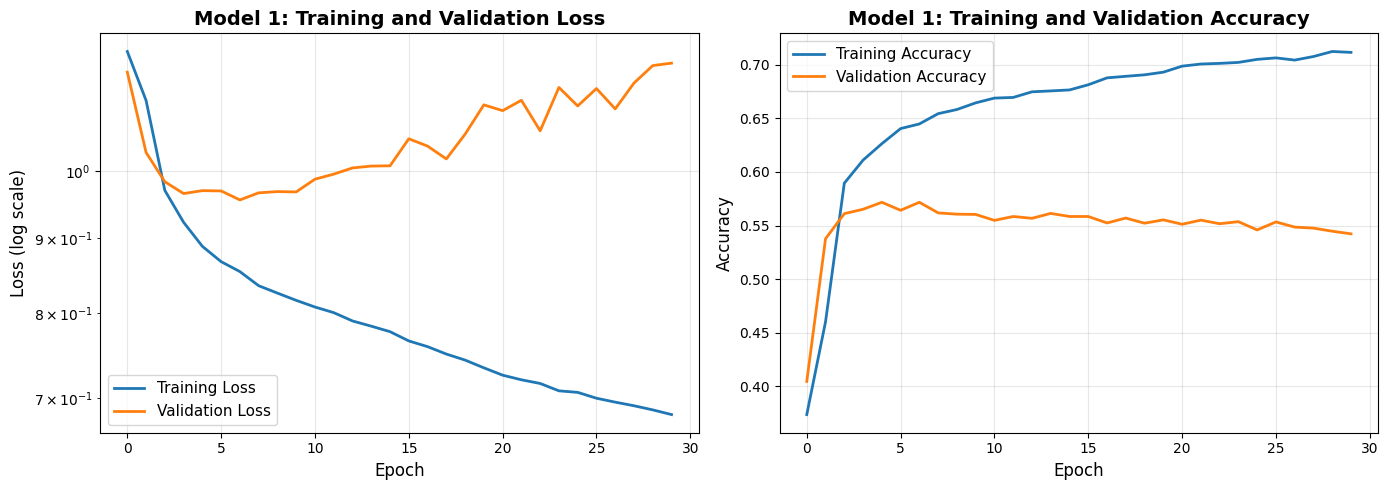

In [11]:
import matplotlib.pyplot as plt

embed_dim = 32
num_heads = 2
ff_dim = 64

optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)

transformer_model_1 = transformModel(X_train_seq, embed_dim, num_heads, ff_dim, top_words, rate=0.2)

transformer_model_1.compile(loss='sparse_categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

history1 = transformer_model_1.fit(
    X_train_seq, y_train,
    validation_split=0.2,   # val data split from training data
    batch_size=32,
    epochs=30,
    shuffle=True,
    verbose=1
)
transformer_model_1.summary()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot (log scale)
axes[0].semilogy(history1.history['loss'], label='Training Loss', linewidth=2)
axes[0].semilogy(history1.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss (log scale)', fontsize=12)
axes[0].set_title('Model 1: Training and Validation Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(history1.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[1].plot(history1.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Model 1: Training and Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Analysis 

Model 1 is a single-layer Transformer-based classification model using learned token and absolute positional embeddings. 

The model converges quickly, with training loss decreasing steadily and validation accuracy rising rapidly in the early epochs.

However, after reaching a peak validation accuracy of around 54%, performance plateaus while training accuracy continues to increase, indicating overfitting. 

This suggests that although the model captures basic sequential patterns effectively, its generalization ability is limited with a single Transformer layer and learned absolute positional encoding.

#### 2.1.2 Second Transformer Model (Model 2)

Epoch 1/30
519/519 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.3696 - loss: 1.2051 - val_accuracy: 0.4080 - val_loss: 1.1616
Epoch 2/30
519/519 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4965 - loss: 1.0814 - val_accuracy: 0.5708 - val_loss: 0.9911
Epoch 3/30
519/519 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5967 - loss: 0.9577 - val_accuracy: 0.5739 - val_loss: 0.9615
Epoch 4/30
519/519 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6172 - loss: 0.9162 - val_accuracy: 0.5662 - val_loss: 0.9636
Epoch 5/30
519/519 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6289 - loss: 0.8867 - val_accuracy: 0.5691 - val_loss: 0.9501
Epoch 6/30
519/519 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6407 - loss: 0.8651 - val_accuracy: 0.5652 - val_loss: 0.9543
Epoch 7/30
519/519 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6507 - loss: 0.8488 - val_accuracy: 0.5672 - val_loss: 0.9574
Epoch 8/30
519/519 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6565 - loss: 0.8347 - val_accuracy: 0.

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 35)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_and_position_embedding_1  │ (None, 35, 32)         │        49,120 │
│ (TokenAndPositionEmbedding)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, 35, 32)         │        21,120 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 168)            │        10,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │           507 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 251,339 (981.80 KB)

 Trainable params: 83,779 (327.26 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 167,560 (654.54 KB)

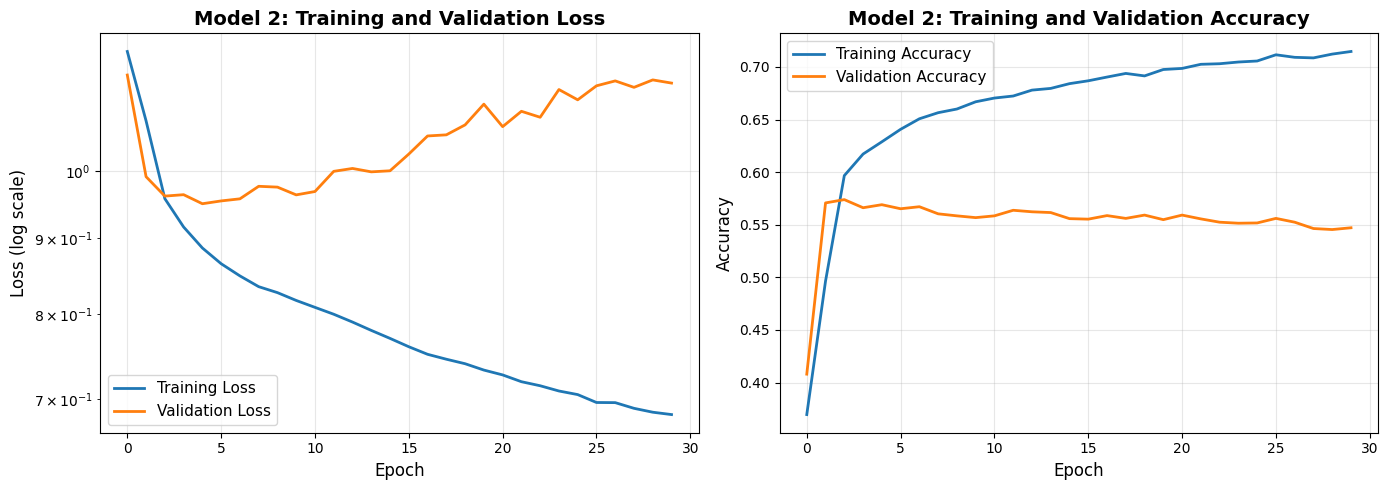

In [12]:
embed_dim = 32
num_heads = 4 # increase 2 ->4 from model 1
ff_dim = 64

optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)

transformer_model_2 = transformModel(X_train_seq, embed_dim, num_heads, ff_dim, top_words, rate=0.2) 

transformer_model_2.compile(loss='sparse_categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

history2 = transformer_model_2.fit(
    X_train_seq, y_train,
    validation_split=0.2,   # val split only from training set
    batch_size=32,
    epochs=30,
    shuffle=True,
    verbose=1
)
transformer_model_2.summary()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot (log scale)
axes[0].semilogy(history2.history['loss'], label='Training Loss', linewidth=2)
axes[0].semilogy(history2.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss (log scale)', fontsize=12)
axes[0].set_title('Model 2: Training and Validation Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(history2.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[1].plot(history2.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Model 2: Training and Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Analysis

Model 2 uses the same single-layer Transformer architecture as Model 1 but increases the number of attention heads from 2 to 4, while keeping other hyperparameters fixed. 

The performance patterns of Model 2 are similar to those observed in Model 1, it converges stably, with training accuracy steadily increasing to around 0.71, indicating improved representational capacity. However, validation accuracy peaks early at approximately 55% and then slightly declines, while validation loss increases over time, suggesting overfitting. 

The plots show that increasing the number of attention heads alone does not improve generalization in our dataset.

### 2.2 CNN Models


In [13]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, Embedding, Input

def create_CNN_model(X, top_words, embed_dim, num_filters, kernel_size, num_dense_layer, use_dropout=False):

	inputs = Input(shape=(X.shape[1],))
	x = Embedding(input_dim=top_words, output_dim=embed_dim)(inputs)

	for filter in num_filters:
		x = Conv1D(filters=filter, kernel_size=kernel_size, activation='relu')(x)
		x = MaxPooling1D(pool_size=2)(x)

	x = Flatten()(x)

	if len(num_dense_layer) > 1:
		for dense_layer in num_dense_layer[:-1]:
			if use_dropout:
				x = Dropout(0.5)(x)
			x = Dense(dense_layer, activation='relu')(x)

	outputs = Dense(num_dense_layer[-1], activation='softmax')(x)

	return Model(inputs=inputs, outputs=outputs)

#### 2.2.1 First CNN Model (Model 3)

Epoch 1/30
519/519 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3964 - loss: 1.0808 - val_accuracy: 0.5105 - val_loss: 1.0345
Epoch 2/30
519/519 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5570 - loss: 0.9431 - val_accuracy: 0.5657 - val_loss: 0.9221
Epoch 3/30
519/519 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6203 - loss: 0.8608 - val_accuracy: 0.5739 - val_loss: 0.9155
Epoch 4/30
519/519 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6501 - loss: 0.8144 - val_accuracy: 0.5655 - val_loss: 0.9304
Epoch 5/30
519/519 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6775 - loss: 0.7621 - val_accuracy: 0.5688 - val_loss: 0.9536
Epoch 6/30
519/519 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7138 - loss: 0.7049 - val_accuracy: 0.5611 - val_loss: 0.9792
Epoch 7/30
519/519 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7426 - loss: 0.6463 - val_accuracy: 0.5549 - val_loss: 1.0520
Epoch 8/30
519/519 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7638 - loss: 0.5929 - val_accuracy: 0.

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 35)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_4 (Embedding)         │ (None, 35, 64)         │        96,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 31, 64)         │        20,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 15, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 960)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 960)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       123,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 744,011 (2.84 MB)

 Trainable params: 248,003 (968.76 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 496,008 (1.89 MB)

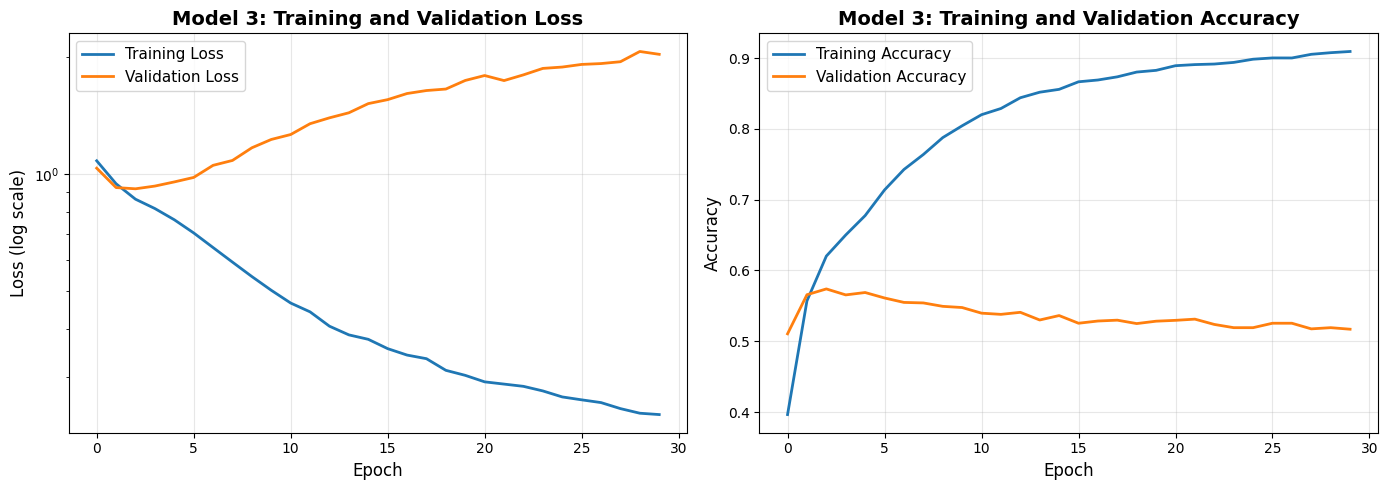

In [14]:
embed_dim = 64

optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)

cnn_model_1 = create_CNN_model(X_train_seq, top_words, embed_dim, [64], 5, [128, 64, 3], True)

cnn_model_1.compile(loss='sparse_categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

history3 = cnn_model_1.fit(
    X_train_seq, y_train,
    validation_split=0.2,   # val comes from training set
    batch_size=32,
    epochs=30,
    shuffle=True,
    verbose=1
)
cnn_model_1.summary()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot (log scale)
axes[0].semilogy(history3.history['loss'], label='Training Loss', linewidth=2)
axes[0].semilogy(history3.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss (log scale)', fontsize=12)
axes[0].set_title('Model 3: Training and Validation Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(history3.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[1].plot(history3.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Model 3: Training and Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Analysis 

Model 3 is a CNN-based sequential model with an Embedding layer (dim=64) followed by one Conv1D layer (64 filters, kernel size=5), MaxPooling, then Flatten + Dense layers (128 → 64 → 3) with dropout (0.5) enabled. 

From the graph the training curve shows a steady downwards trend for the loss curve, while the validation does shows a decrease initial, it is then showing a upwards trend, and climbing above the initial training curve. Indicating that the that the model is overfitting. 

The model's accuracy curve shows a similar overfitting trend as well. The training curve shows a good trend, but the validation curve initially shows an increasing trend, but the then declines in accuracy and finally hovering around 52%, which shows that the model is overfitting. 


#### 2.2.2 Second CNN Model (Model 4)

Epoch 1/30
519/519 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3939 - loss: 1.0816 - val_accuracy: 0.4398 - val_loss: 1.0505
Epoch 2/30
519/519 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4776 - loss: 1.0155 - val_accuracy: 0.5561 - val_loss: 0.9560
Epoch 3/30
519/519 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6056 - loss: 0.8958 - val_accuracy: 0.5684 - val_loss: 0.9326
Epoch 4/30
519/519 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6567 - loss: 0.8069 - val_accuracy: 0.5635 - val_loss: 0.9505
Epoch 5/30
519/519 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7209 - loss: 0.7062 - val_accuracy: 0.5491 - val_loss: 1.0206
Epoch 6/30
519/519 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7845 - loss: 0.5783 - val_accuracy: 0.5339 - val_loss: 1.1203
Epoch 7/30
519/519 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8323 - loss: 0.4534 - val_accuracy: 0.5223 - val_loss: 1.3313
Epoch 8/30
519/519 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8731 - loss: 0.3514 - val_accuracy: 0.

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 35)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_5 (Embedding)         │ (None, 35, 64)         │        96,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 31, 64)         │        20,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 15, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 11, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 5, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 640)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 640)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 744,395 (2.84 MB)

 Trainable params: 248,131 (969.26 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 496,264 (1.89 MB)

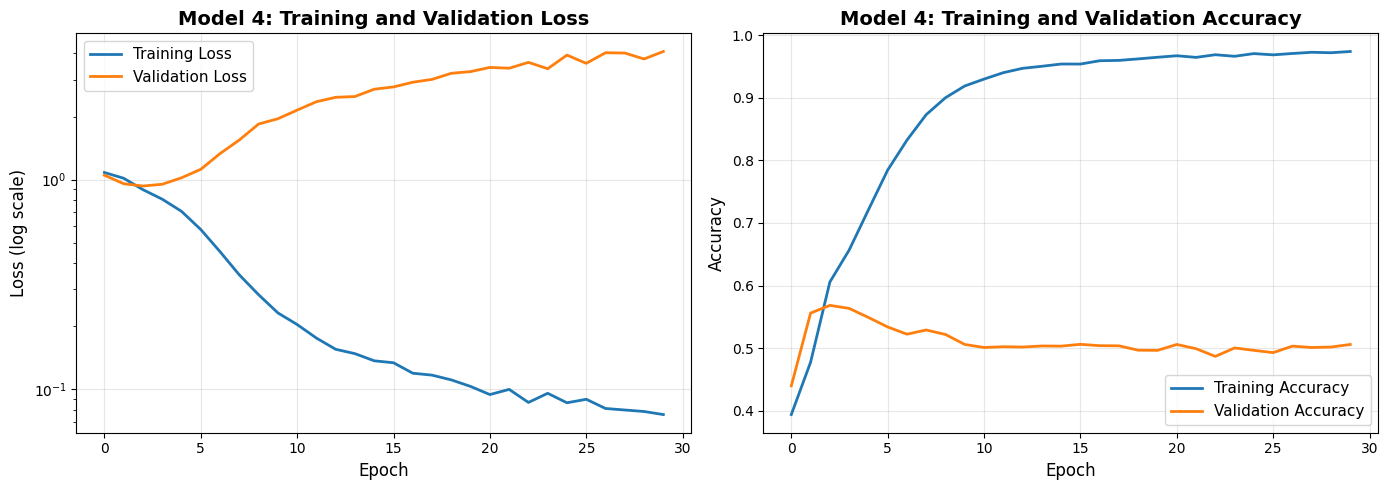

In [15]:
embed_dim = 64

optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)

# change num filter from [64]->[64,128]
cnn_model_2 = create_CNN_model(X_train_seq, top_words, embed_dim, [64,128], 5, [128, 64, 3], True)

cnn_model_2.compile(loss='sparse_categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

history4 = cnn_model_2.fit(
    X_train_seq, y_train,
    validation_split=0.2, # val comes from training set
    batch_size=32,
    epochs=30,
    shuffle=True,
    verbose=1
)

cnn_model_2.summary()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot (log scale)
axes[0].semilogy(history4.history['loss'], label='Training Loss', linewidth=2)
axes[0].semilogy(history4.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss (log scale)', fontsize=12)
axes[0].set_title('Model 4: Training and Validation Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(history4.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[1].plot(history4.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Model 4: Training and Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Analysis 

For the CNN model 2, extended CNN model 1, and added another initial filter of 64.

From the graph the training curve shows a steady downwards trend for the loss curve, while the validation does shows a decrease trend initially, but it is then showing a upwards trend, and climbing above the initial training curve. Indicating that the that the model is overfitting. Additionally, the training curves shows a smooth downward curve trend indicating that model is learning training features better, but not generalizable features. 

The model's accuracy curve shows a similar overfitting trend as well. The training curve shows a good trend, but the validation curve initial shows an increasing trend, but the then declines in accuracy and finally hovering around 51%, which shows that the model is overfitting. 

### 2.3 Adding a Second Transformer Layer (Model 5)

In [19]:
# check with GPT about if we implement final score correctly
import numpy as np
from sklearn.metrics import precision_recall_fscore_support

'''
Class mapping:
2 -> Positive
1 -> Neutral
0 -> Negative
'''

# ======== Model predictions ========
model_1_pred = transformer_model_1.predict(X_test_seq)
model_1_pred_classes = np.argmax(model_1_pred, axis=1)

model_2_pred = transformer_model_2.predict(X_test_seq)
model_2_pred_classes = np.argmax(model_2_pred, axis=1)


# ======== Final Score function ========
def get_final_score(y_true, y_pred):
    # Get per-class precision, recall, and F1
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=[0, 1, 2],
        zero_division=0
    )

    # F2 score for negative class (class 0)
    beta = 2
    p_neg = precision[0]
    r_neg = recall[0]
    f2_negative = (1 + beta**2) * p_neg * r_neg / (beta**2 * p_neg + r_neg + 1e-9)

    # F1 scores for neutral and positive
    f1_neutral = f1[1]
    f1_positive = f1[2]

    # Final score
    final_score = (f2_negative + f1_neutral + f1_positive) / 3
    return round(float(final_score), 4)


# ======== Compute scores ========
final_score_transformer_1 = get_final_score(y_test, model_1_pred_classes)
final_score_transformer_2 = get_final_score(y_test, model_2_pred_classes)

print("Transformer Model 1 Final Score:", final_score_transformer_1)
print("Transformer Model 2 Final Score:", final_score_transformer_2)

162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Transformer Model 1 Final Score: 0.5382
Transformer Model 2 Final Score: 0.5445


From the fianl score, we can see that the model 2 performed slightly better than model 1.

Although their final score are pretty close, we have to choose one to add the second transformer layer, so we choose model 2.

In [17]:
def transformModel_2(X, embed_dim, num_heads, ff_dim, top_words, rate):
	inputs = Input(shape=(X.shape[1],))
	x = TokenAndPositionEmbedding(X.shape[1], top_words, embed_dim)(inputs)
	x = TransformerBlock(embed_dim, num_heads, ff_dim, rate)(x)
	x = TransformerBlock(embed_dim, num_heads, ff_dim, rate)(x)

	x = GlobalAveragePooling1D()(x)
	x = Dropout(0.5)(x)
	x = Dense(64, activation='relu', kernel_regularizer=l2(0.001))(x)
	x = Dense(168, activation='relu', kernel_regularizer=l2(0.001))(x)

	outputs = Dense(3, activation='softmax', kernel_initializer='glorot_uniform', kernel_regularizer=l2(0.001))(x)

	return Model(inputs=inputs, outputs=outputs)

Epoch 1/30
519/519 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.3778 - loss: 1.2010 - val_accuracy: 0.4644 - val_loss: 1.1218 - learning_rate: 5.0000e-04
Epoch 2/30
519/519 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.5457 - loss: 1.0504 - val_accuracy: 0.5693 - val_loss: 1.0022 - learning_rate: 5.0000e-04
Epoch 3/30
519/519 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.5904 - loss: 0.9744 - val_accuracy: 0.5703 - val_loss: 0.9825 - learning_rate: 5.0000e-04
Epoch 4/30
519/519 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.6128 - loss: 0.9282 - val_accuracy: 0.5698 - val_loss: 0.9785 - learning_rate: 5.0000e-04
Epoch 5/30
519/519 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.6255 - loss: 0.8989 - val_accuracy: 0.5713 - val_loss: 0.9594 - learning_rate: 5.0000e-04
Epoch 6/30
519/519 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.6377 - loss: 0.8730 - val_accuracy: 0.5751 - val_loss: 0.9575 - learning_rate: 5.0000e-04
Epoch 7/30
519/519 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 

Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 35)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_and_position_embedding_3  │ (None, 35, 32)         │        49,120 │
│ (TokenAndPositionEmbedding)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_4             │ (None, 35, 32)         │        21,120 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_5             │ (None, 35, 32)         │        21,120 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_3      │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 168)            │        10,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 3)              │           507 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 314,699 (1.20 MB)

 Trainable params: 104,899 (409.76 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 209,800 (819.54 KB)

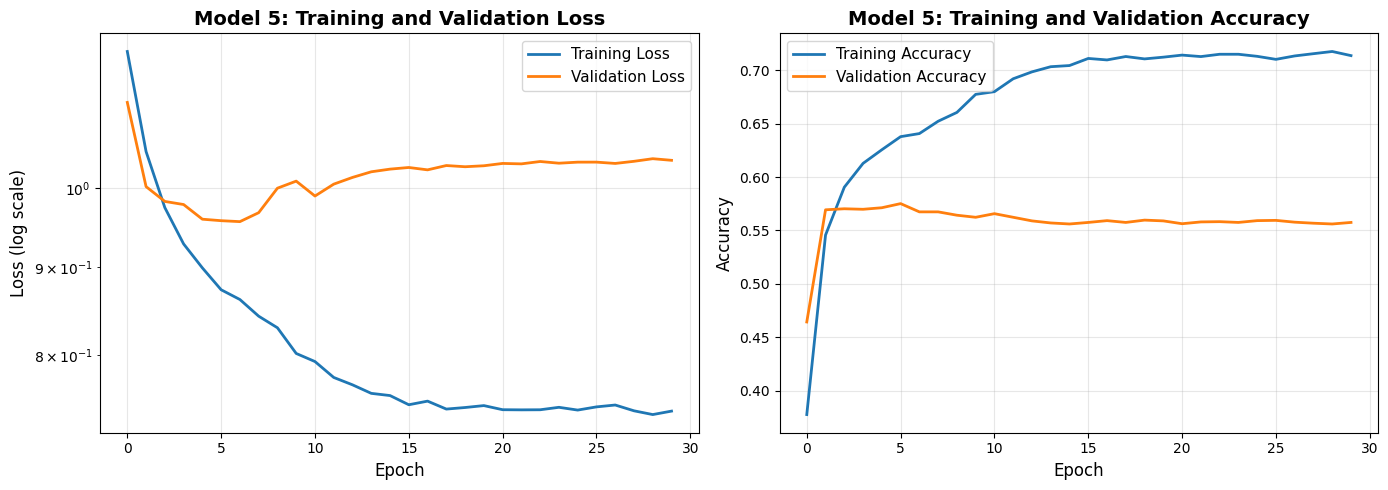

In [20]:
# using the same parameters with model 2, because model 2 final score is slightly higher in this run
embed_dim = 32
num_heads = 4 
ff_dim = 64

optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)

lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
	monitor='val_loss',
	factor=0.5,
	patience=2,
	min_lr=1e-5,
	verbose=1
)
transformer_model_3 = transformModel_2(X_train_seq, embed_dim, num_heads, ff_dim, top_words, rate=0.2)

transformer_model_3.compile(loss='sparse_categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

history5 = transformer_model_3.fit(
    X_train_seq, y_train,
    validation_split=0.2, # val comes from training set
    batch_size=32,
    epochs=30,
    shuffle=True,
    verbose=1,
    callbacks=[lr_scheduler]
)

transformer_model_3.summary()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot (log scale)
axes[0].semilogy(history5.history['loss'], label='Training Loss', linewidth=2)
axes[0].semilogy(history5.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss (log scale)', fontsize=12)
axes[0].set_title('Model 5: Training and Validation Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(history5.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[1].plot(history5.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Model 5: Training and Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Analysis

Using the same parameter of model 1, we extended it by adding another transformer layer to the model. 

Adding another transformer layer did not make the model performed better, but instead it made the validation curve much more steady after a couple of epochs instead of having an increasing trend, while the training curves shows a steady decrease in the loss curves. This indicates that adding another transformer layer did improve with the model overfitting to the data compared to previous model, but it did not improve the model performance (Model 1 validation accuracy is approximatly 54%, and model 5 is 55.75%). Additionally, the validation loss has become steady, indicating the model generalization remains limited. Thus adding another transformer layer did not improve the generalization, even though it reduced the overfitting compared to transformer model 1, and 2.  

The accuracy curve shows a similar pattern, where the training accuracy increases gradually, and then hovering around 70%, but the validation increases initially, but then remains steady around 56% accuracy. 

Overall, adding another transformer layer improves training stability, but it does not meaningfully enhances generalization performance. 

### 2.4 Performance Comparison
#### 2.4.1 Final Score Comparison

162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Model 1 Final score:  0.5382
Model 2 Final score:  0.5445
Model 3 (2 Transformer) Final score:  0.5554
Model 4 (CNN model 1) Final score:  0.5314
Model 5 (CNN model 2) Final score:  0.5135


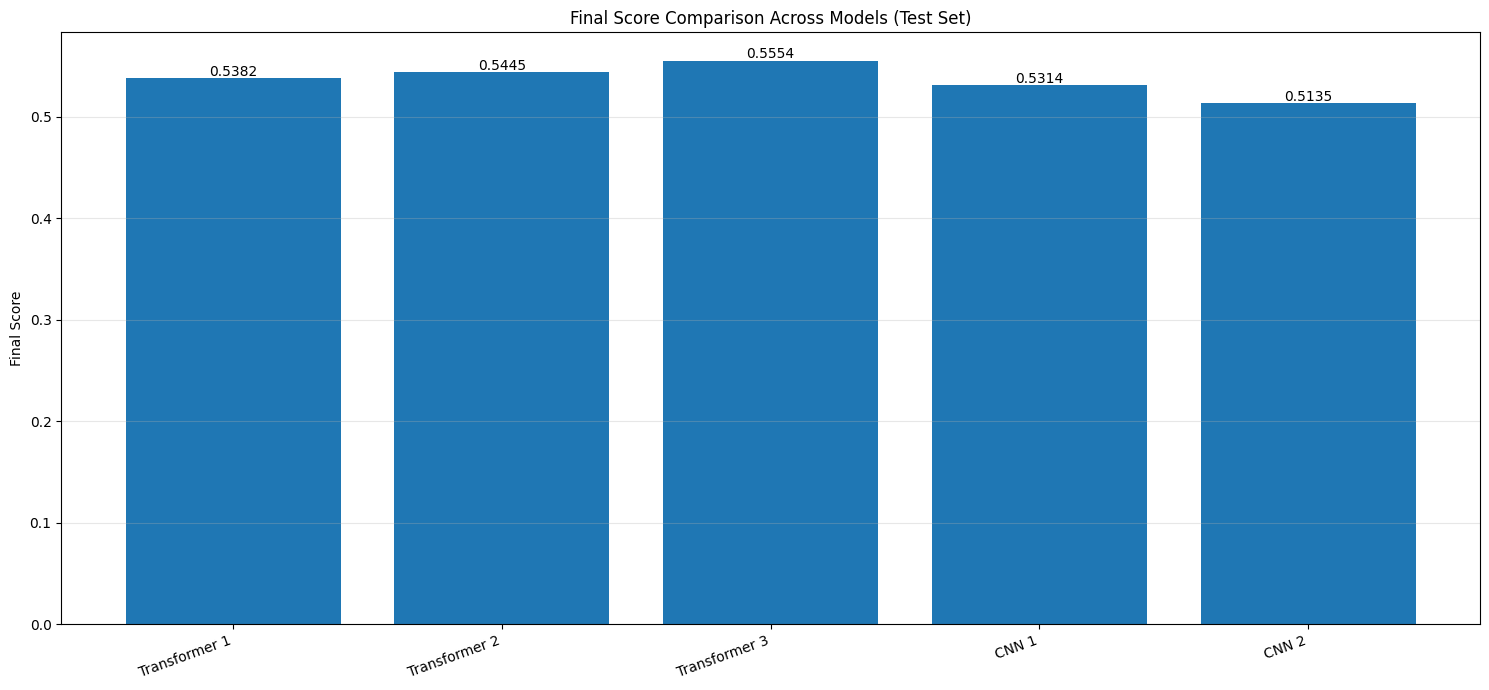

In [21]:
model_3_pred = cnn_model_1.predict(X_test_seq)
model_3_pred_classes = np.argmax(model_3_pred, axis=1)

model_4_pred = cnn_model_2.predict(X_test_seq)
model_4_pred_classes = np.argmax(model_4_pred, axis=1)

model_5_pred = transformer_model_3.predict(X_test_seq)
model_5_pred_classes = np.argmax(model_5_pred, axis=1)

f_transformer_3 = get_final_score(y_test, model_5_pred_classes)
f_CNN_1 = get_final_score(y_test, model_3_pred_classes)
f_CNN_2 = get_final_score(y_test, model_4_pred_classes)

print("Model 1 Final score: ", final_score_transformer_1)
print("Model 2 Final score: ", final_score_transformer_2)
print("Model 3 (2 Transformer) Final score: ", f_transformer_3)
print("Model 4 (CNN model 1) Final score: ", f_CNN_1)
print("Model 5 (CNN model 2) Final score: ", f_CNN_2)


# ======== Visualization: Bar chart ========
model_names = [
    "Transformer 1",
    "Transformer 2",
    "Transformer 3",
    "CNN 1",
    "CNN 2"

]

final_scores = [
    final_score_transformer_1,
    final_score_transformer_2,
    f_transformer_3,
    f_CNN_1,
    f_CNN_2 ]

plt.figure(figsize=(15, 7))
plt.bar(model_names, final_scores)

# optional: add value labels on bars
for i, v in enumerate(final_scores):
    plt.text(i, v + 0.002, f"{v:.4f}", ha="center", fontsize=10)

plt.ylabel("Final Score")
plt.title("Final Score Comparison Across Models (Test Set)")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Analysis 

From the evaluation metric, as we discussed in the preparation section, we decided to go with a weighted F Score as we care more about negative reviews, as we do not want to advertise near negative tweets. 

From the Weighted F score, and out of all the transformer model, model 3 with a head of 4, embedd dim of 32, ff_dim of 32, and another transformer layer gave us the best result of 0.5554 out of all the other models. While CNN did perform similar to one another as the difference in F score is approximately 0.02 between the model, it is still low compared to a transformer, indicating that for a smaller text data size, transformer model 3 is the best model to use for our this dataset. 

However, due to small dataset, our model did not learn/extract useful information for it to be trained on, which result in all the model having poor final score performance. 

#### 2.4.2 ROC Curve And AUROC curve 

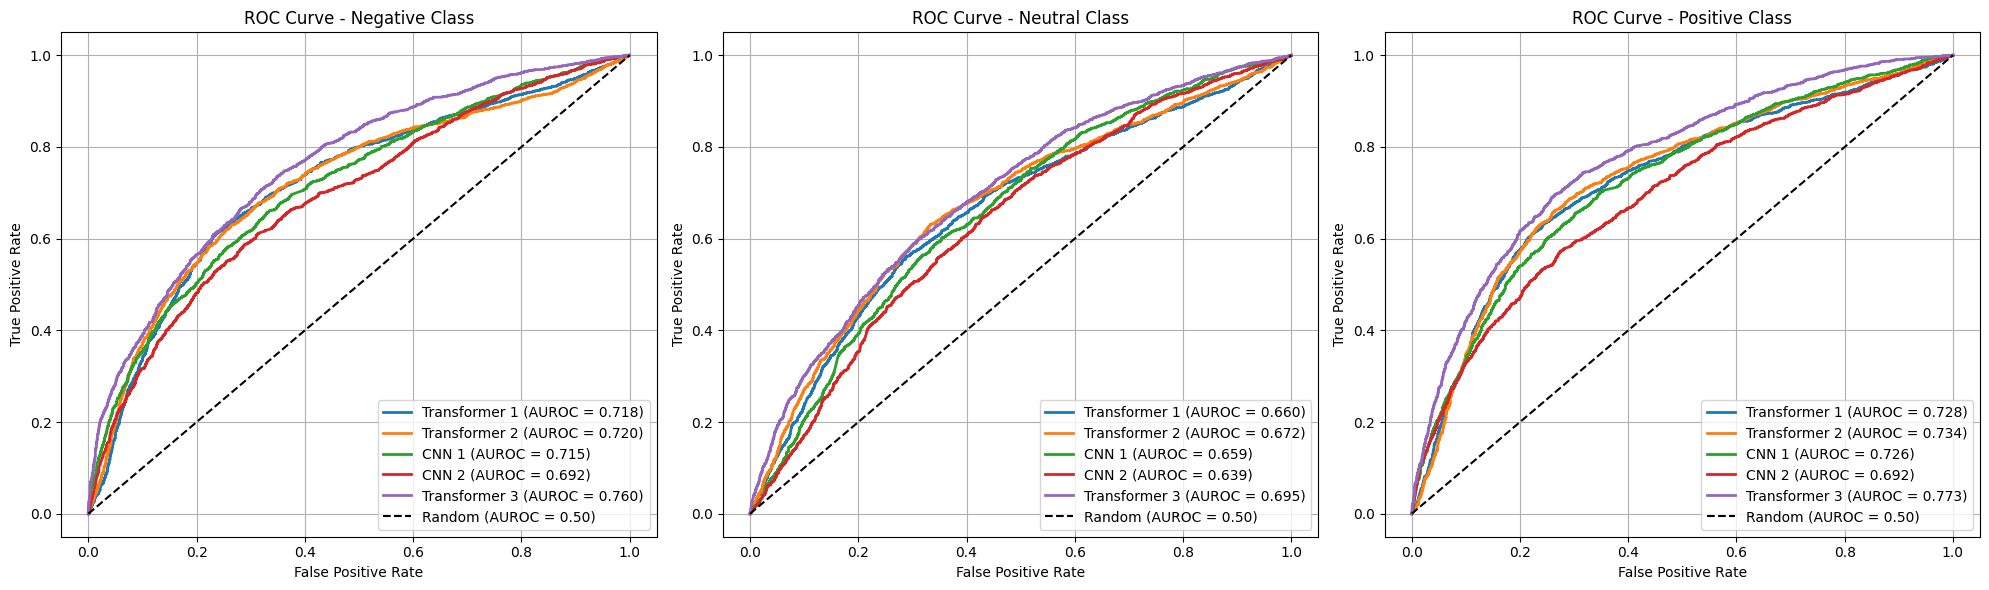

In [ ]:
#Asked GPT to help debug ROC curve
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

models_pred_result = {
	"Transformer 1": model_1_pred,
	"Transformer 2": model_2_pred,
	"CNN 1": model_3_pred,
	"CNN 2": model_4_pred,
	"Transformer 3": model_5_pred
}

class_names = ["Negative", "Neutral", "Positive"]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for index, class_name in enumerate(class_names):
	for model_name, probs in models_pred_result.items():
		fpr, tpr, _ = roc_curve(
			y_test_bin[:, index],
			probs[:, index]
		)
		roc_auc = auc(fpr, tpr)
		axes[index].plot(
			fpr,
			tpr,
			linewidth=2,
			label=f"{model_name} (AUROC = {roc_auc:.3f})"
		)
		
	axes[index].plot([0, 1], [0, 1], "k--", label="Random (AUROC = 0.50)")
	
	axes[index].set_xlabel("False Positive Rate")
	axes[index].set_ylabel("True Positive Rate")
	axes[index].set_title(f"ROC Curve - {class_name} Class")
	axes[index].legend(loc="lower right")
	axes[index].grid(True)

plt.tight_layout()
plt.show()


#### Analysis 

Out of all the ROC curves, transformer 3 seems to perform the best out of all the other models, and this aligns with our weighted F score as well. While CNN 2 is the worst performer out of all the models as well, consistently below the 0.7 value in all three classes. 

For negative class, most models perform similar to one another except for transformer 3, while the CNN 2 performed the poorly out of all the models in the negative class. 

In the neutral class, all the models performed similar to one another and reflected by the AUROC values, indicating that predicting the neutral class is the most difficult one out of all three classes. 

Lastly, for the positive class, the model CNN model 2 again performed the poorest out of all the model, and transformer 3 performed marginally better than the rest of the models.

From this graphs, we can conclude that the transformer models performed better compared to a CNN model, and hyperparameter tunning the transformer model does not improve the performance significantly, as the overall dataset quality is not good enough for the model to learn meaningful patterns, this is maybe because the text or the label are not useful.  

While theses result might not be good, but this also brings insights for our business case, as all of the transformer model had the best ROC curves in for the positive and negative classes, which we cared more about. 

#### 2.4.3 Statistical Comparison

In [22]:
from statsmodels.stats.contingency_tables import mcnemar
import itertools
import pprint

result = {}
models_pred_classes = {
  "Transformer 1": model_1_pred_classes,
  "Transformer 2": model_2_pred_classes,
  "CNN 1": model_3_pred_classes,
  "CNN 2": model_4_pred_classes,
  "Transformer 3": model_5_pred_classes
}

def mcNemar_table(y_true, model_1_pred, model_2_pred):
	model1_correct = model_1_pred == y_true
	model2_correct = model_2_pred == y_true

	both_correct = np.sum(model1_correct & model2_correct)
	model1_correct_model2_wrong = np.sum(model1_correct & ~model2_correct)
	model2correct_model1_wrong = np.sum(~model1_correct & model2_correct)
	both_wrong = np.sum(~model1_correct & ~model2_correct)

	return np.array([[both_correct, model1_correct_model2_wrong], [model2correct_model1_wrong, both_wrong]])

model_names = ["Transformer 1", "Transformer 2", "CNN 1", "CNN 2", "Transformer 3"]

for model1, model2 in itertools.combinations(model_names, 2):
	table = mcNemar_table(y_test, models_pred_classes[model1], models_pred_classes[model2])
	result_mcnemar = mcnemar(table, exact=False, correction=True)
	result[(model1, model2)] = {
		"statistic": result_mcnemar.statistic,
		"p-value": result_mcnemar.pvalue
	}



# ask GPT to help format the McNemar test results into a DataFrame
import pandas as pd
import numpy as np

model_names = ["Transformer 1", "Transformer 2", "CNN 1", "CNN 2", "Transformer 3"]

# Initialize empty DataFrame
mcnemar_table_df = pd.DataFrame(
    "",
    index=model_names,
    columns=model_names
)

# Fill table
for (model1, model2), res in result.items():
    stat = round(res["statistic"], 4)
    pval = round(res["p-value"], 4)
    cell_value = f"{stat} (p={pval})"
    
    mcnemar_table_df.loc[model1, model2] = cell_value
    mcnemar_table_df.loc[model2, model1] = cell_value

# Diagonal
for model in model_names:
    mcnemar_table_df.loc[model, model] = "-"

mcnemar_table_df

,Transformer 1,Transformer 2,CNN 1,CNN 2,Transformer 3
Transformer 1,-,2.7257 (p=0.0987),1.9894 (p=0.1584),15.1593 (p=0.0001),4.9589 (p=0.026)
Transformer 2,2.7257 (p=0.0987),-,6.4262 (p=0.0112),24.2149 (p=0.0),0.7338 (p=0.3917)
CNN 1,1.9894 (p=0.1584),6.4262 (p=0.0112),-,6.934 (p=0.0085),10.9267 (p=0.0009)
CNN 2,15.1593 (p=0.0001),24.2149 (p=0.0),6.934 (p=0.0085),-,33.8293 (p=0.0)
Transformer 3,4.9589 (p=0.026),0.7338 (p=0.3917),10.9267 (p=0.0009),33.8293 (p=0.0),-


#### Analysis

From the statistical result, we can see that:

1. Transformer models differ significantly between the CNN models in most pairwise comparison where most of the P value is less than 0.05 (except Transformer 1 and CNN1), suggesting a difference in how these architectures makes a classification decisions. 

2. CNN 2 shows a statistical difference with all other models, we are not sure why this happened, this may require future analysis.

3. In CNN models, CNN1 and CNN2 have significant difference with each other,because the p value is 0.0085, suggesting the filter layer influence the model behavior.

## 3.Using RoPE

In [23]:
# using RotaryEmbedding from Keras Hub on transformer 3

# pip install keras-hub

import keras_hub
import tensorflow as tf
from tensorflow.keras.layers import Layer, Embedding

class TokenEmbeddingOnly(Layer):
    def __init__(self, vocab_size, embed_dim):
        super().__init__()
        self.token_emb = Embedding(input_dim=vocab_size, output_dim=embed_dim, trainable=True)

    def call(self, x):
        return self.token_emb(x)

def transformModel_2_rope_simple(X, embed_dim, num_heads, ff_dim, top_words, rate):
    inputs = Input(shape=(X.shape[1],))

    # token embedding only
    x = TokenEmbeddingOnly(top_words, embed_dim)(inputs)

    #add RoPE 
    x = keras_hub.layers.RotaryEmbedding()(x)  

    # keep the original TransformerBlock
    x = TransformerBlock(embed_dim, num_heads, ff_dim, rate)(x)
    x = TransformerBlock(embed_dim, num_heads, ff_dim, rate)(x)

    x = GlobalAveragePooling1D()(x)
    x = Dropout(0.5)(x)
    x = Dense(64, activation='relu', kernel_regularizer=l2(0.001))(x)
    x = Dense(168, activation='relu', kernel_regularizer=l2(0.001))(x)
    outputs = Dense(3, activation='softmax', kernel_initializer='glorot_uniform',
                    kernel_regularizer=l2(0.001))(x)
    return Model(inputs=inputs, outputs=outputs)


c:\Users\Zheng\miniconda3\envs\mlenv3_11\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Epoch 1/30
519/519 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.3778 - loss: 1.2011 - val_accuracy: 0.4126 - val_loss: 1.1613 - learning_rate: 5.0000e-04
Epoch 2/30
519/519 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.5332 - loss: 1.0598 - val_accuracy: 0.5647 - val_loss: 1.0016 - learning_rate: 5.0000e-04
Epoch 3/30
519/519 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.5900 - loss: 0.9706 - val_accuracy: 0.5729 - val_loss: 0.9774 - learning_rate: 5.0000e-04
Epoch 4/30
519/519 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.6244 - loss: 0.9124 - val_accuracy: 0.5708 - val_loss: 0.9662 - learning_rate: 5.0000e-04
Epoch 5/30
519/519 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.6572 - loss: 0.8543 - val_accuracy: 0.5638 - val_loss: 0.9904 - learning_rate: 5.0000e-04
Epoch 6/30
514/519 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7094 - loss: 0.7706
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
519/519 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.691

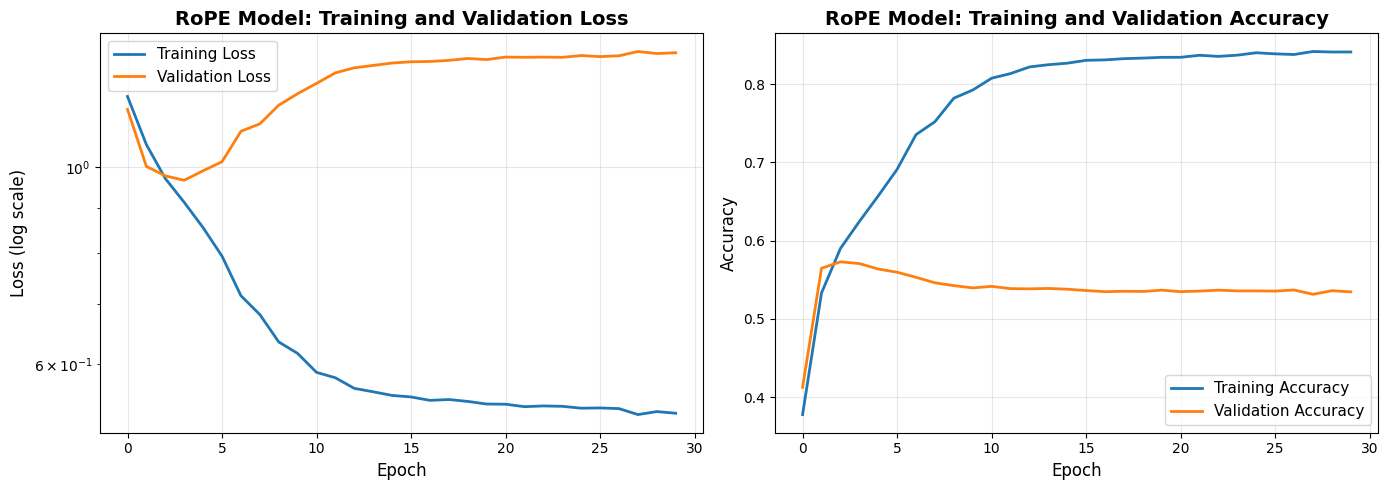

In [27]:
# GPT debug add optimizer

optimizer_rope = tf.keras.optimizers.Adam(learning_rate=0.0005)

lr_scheduler_rope = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-5,
    verbose=1
)

transformer_model_rope = transformModel_2_rope_simple(
    X_train_seq, embed_dim, num_heads, ff_dim, top_words, rate=0.2
)

transformer_model_rope.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=optimizer_rope,
    metrics=['accuracy'],
)

history_rope = transformer_model_rope.fit(
    X_train_seq, y_train,
    validation_split=0.2,
    batch_size=32,
    epochs=30,
    shuffle=True,
    verbose=1,
    callbacks=[lr_scheduler_rope]
)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot (log scale)
axes[0].semilogy(history_rope.history['loss'], label='Training Loss', linewidth=2)
axes[0].semilogy(history_rope.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss (log scale)', fontsize=12)
axes[0].set_title('RoPE Model: Training and Validation Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(history_rope.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[1].plot(history_rope.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('RoPE Model: Training and Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



In [28]:
rope_pred = transformer_model_rope.predict(X_test_seq)
rope_pred_classes = np.argmax(rope_pred, axis=1)

f_rope = get_final_score(y_test, rope_pred_classes)
print("Transformer 3 (RoPE) Final score:", f_rope)


162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Transformer 3 (RoPE) Final score: 0.5256


In [26]:
table = mcNemar_table(y_test, model_5_pred_classes, rope_pred_classes)
result_mcnemar = mcnemar(table, exact=False, correction=True)

print("McNemar table:\n", table)
print("statistic:", result_mcnemar.statistic)
print("p-value:", result_mcnemar.pvalue)


McNemar table:
 [[2214  669]
 [ 520 1780]]
statistic: 18.422203532380152
p-value: 1.7698366618322325e-05


#### Analysis
We Used Rotary Positional Encoding implemented via Keras Hub, the RoPE-based Transformer achieves a slightly lower final score (0.5256) compared to the baseline transformer model 3 (final score: 0.5554).

However, McNemar’s test shows a statistically significant difference in predictions (p < 0.05), indicating that RoPE changes model behavior without providing a clear performance improvement.